<a href="https://colab.research.google.com/github/ranjeetai/AI/blob/main/vision_transformer_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformers (ViT) from Scratch in PyTorch
This notebook is a companion to the blog post on training ViTs from scratch.
We'll build a simple ViT architecture, train it on CIFAR-10, and walk through
each stage in detail.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

train_set = datasets.CIFAR10(root='./content/data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./content/data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64)


100%|██████████| 170M/170M [00:04<00:00, 35.3MB/s]


In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, emb_size=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, emb_size, H', W')
        x = x.flatten(2)  # (B, emb_size, N)
        x = x.transpose(1, 2)  # (B, N, emb_size)
        return x


In [5]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_size=128, heads=4, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(emb_size)
        self.mha = nn.MultiheadAttention(emb_size, heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(emb_size)
        self.ff = nn.Sequential(
            nn.Linear(emb_size, emb_size * 4),
            nn.GELU(),
            nn.Linear(emb_size * 4, emb_size)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.dropout(self.mha(self.ln1(x), self.ln1(x), self.ln1(x))[0])
        x = x + self.dropout(self.ff(self.ln2(x)))
        return x


In [6]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_size=128, depth=6, heads=4, n_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size=img_size, patch_size=patch_size, emb_size=emb_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        self.pos_embed = nn.Parameter(torch.randn(1, (img_size // patch_size)**2 + 1, emb_size))
        self.transformer = nn.Sequential(*[
            TransformerEncoderBlock(emb_size, heads)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(emb_size)
        self.head = nn.Linear(emb_size, n_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.transformer(x)
        x = self.norm(x)
        return self.head(x[:, 0])


In [7]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (output.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [8]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item() * x.size(0)
            correct += (output.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [9]:
model = VisionTransformer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

train_losses, test_losses = [], []
epochs = 10
for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f"Epoch {epoch+1}/{epochs}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | Test Loss={test_loss:.4f}, Acc={test_acc:.4f}")


Epoch 1/10: Train Loss=1.8818, Acc=0.3115 | Test Loss=1.6729, Acc=0.3955
Epoch 2/10: Train Loss=1.5836, Acc=0.4304 | Test Loss=1.4746, Acc=0.4766
Epoch 3/10: Train Loss=1.4659, Acc=0.4736 | Test Loss=1.3668, Acc=0.5115
Epoch 4/10: Train Loss=1.3762, Acc=0.5048 | Test Loss=1.3269, Acc=0.5245
Epoch 5/10: Train Loss=1.3069, Acc=0.5313 | Test Loss=1.2610, Acc=0.5487
Epoch 6/10: Train Loss=1.2449, Acc=0.5528 | Test Loss=1.2098, Acc=0.5654
Epoch 7/10: Train Loss=1.1942, Acc=0.5709 | Test Loss=1.2001, Acc=0.5758
Epoch 8/10: Train Loss=1.1438, Acc=0.5922 | Test Loss=1.1994, Acc=0.5727
Epoch 9/10: Train Loss=1.1066, Acc=0.6017 | Test Loss=1.1367, Acc=0.5975
Epoch 10/10: Train Loss=1.0682, Acc=0.6180 | Test Loss=1.1366, Acc=0.6008


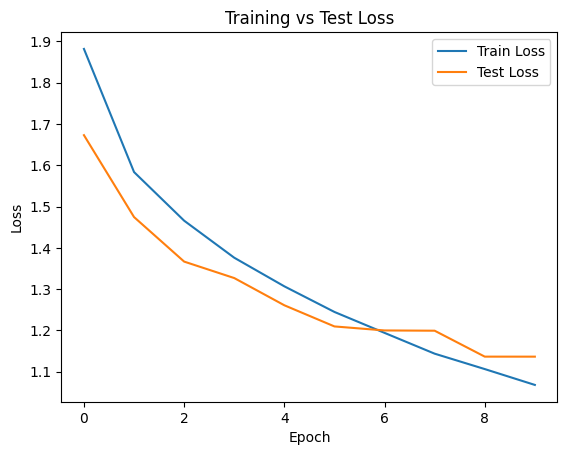

In [10]:
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Test Loss")
plt.show()
